# Advanced RAG Architechture
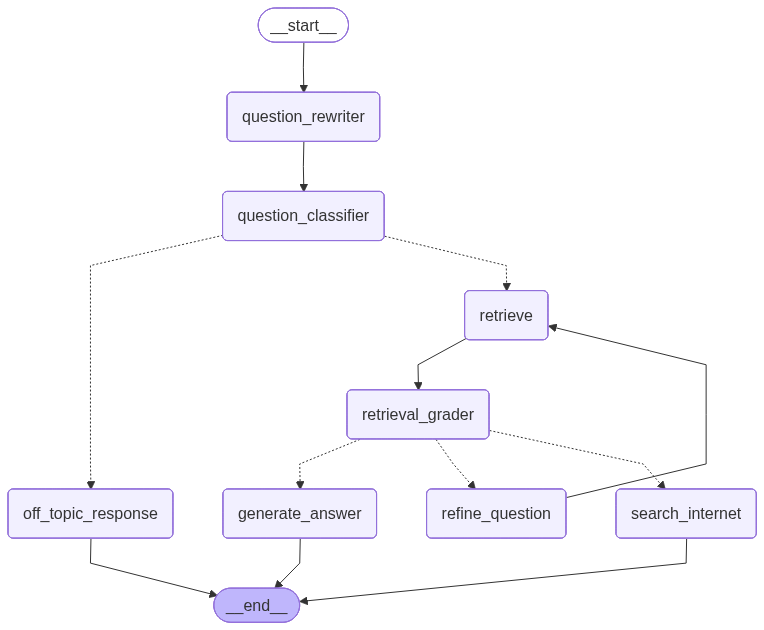

In [32]:
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv(override=True)

True

In [33]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_openai import ChatOpenAI

## Initialize embedding model

In [34]:
def get_gemini_embedding_model():
    return GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

## Link vector with embedding model
```
FAISS reads the saved index files (essentially a mathematical map of your document chunks)

Mathematical Map
- when you ask a question, your question also gets embedded into numbers
- FAISS finds the chunks whose numbers are closest to your question's numbers.

Saved Index Files
When you call FAISS.load_local(), it reads two key files:
faiss_index_financial/
    ├── index.faiss   ← the actual vectors + fast-search structure
    └── index.pkl     ← maps each vector back to its original text chunk
index.faiss is the math, index.pkl is the lookup table that says "vector #47 came from this piece of text."
```

In [35]:
def get_vectorstore():
    """Load the FAISS vector store."""
    VECTOR_DB_DIR = "13.1_RAG_Embedding"
    VECTOR_DB_SUBDIR = os.path.join(VECTOR_DB_DIR, "faiss_index_financial")
    vectorstore = FAISS.load_local(
        VECTOR_DB_SUBDIR,
        embeddings=get_gemini_embedding_model(),
        allow_dangerous_deserialization=True
    )

    return vectorstore

## LLM Initialization

In [36]:
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",  # or another Groq model you have access to
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.2,
        max_tokens=2500,
    )
llm = get_groq_llm()

In [37]:
"""
# Vectror Store initialization
1. Load Database directory with embedding model
2. Define seach arguments
3. Call Retriever
4. Invoke wherever you need
"""
embeddings = get_gemini_embedding_model()
vectorstore = get_vectorstore()

search_kwargs = {"k": 3}

# This is a metadata filter — it narrows down which chunks are even eligible to be searched before FAISS does the similarity math.
roles = ["scientist"]  # Example roles to filter by
if roles:
    # FAISS supports $in filter for metadata
    search_kwargs["filter"] = {"role": {"$in": roles}}

vector_retriever = vectorstore.as_retriever(search_kwargs=search_kwargs)

## Chaining concept in LangChain

In [38]:
on_topic_template = """
Answer the question based on the following context and the Chathistory.
Especially take the latest question into consideration:

Chathistory: {history}
Context: {context}
Question: {question}
"""

off_topic_template = """
When a user asks an off-topic question (not related to JPM 2023 pdf/report or JPM SE Annual report/pdf ):
Provide a short, polite answer to acknowledge their query.
Immediately and firmly remind the user that you are built specifically for finance-related queries.
Encourage them to return to finance-related questions, since that’s where you can provide real value.
If relevant, use the chat history to make your reminder more natural and connected to past discussions.

Always maintain a friendly but professional tone.

chat_history: {history}
Question: {question}
"""

In [39]:
from langchain_core.prompts import ChatPromptTemplate

on_topic_prompt = ChatPromptTemplate.from_template(on_topic_template)
rag_chain = on_topic_prompt | llm

In [40]:
off_topic_llm = get_groq_llm()

off_topic_prompt = ChatPromptTemplate.from_template(off_topic_template)
off_topic_rag_chain = off_topic_prompt | off_topic_llm

# RAG

In [41]:
from typing import TypedDict, List, Annotated, Sequence
from pydantic import BaseModel, Field

from langchain_core.documents import Document
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_community.utilities import SerpAPIWrapper

In [42]:
class AgentState(TypedDict):
    # Enhanced with add_messages reducer
    messages: Annotated[Sequence[BaseMessage], add_messages]

    # Standard keys (these will overwrite when updated)
    documents: List[Document]
    on_topic: str
    rephrased_question: str
    proceed_to_generate: bool
    rephrase_count: int
    question: HumanMessage

class GradeQuestion(BaseModel):
    score: str = Field(
        description="Question is about the specified topics? If yes -> 'Yes' if not -> 'No'"
    )

class GradeDocument(BaseModel):
    score: str = Field(
        description="Document is relevant to the question? If yes -> 'Yes' if not -> 'No'"
    )


In [43]:
def question_rewriter(state: AgentState):
    """
        # STEP 1: The Clean Slate
        # STEP 2: The Deduplication Check
        # STEP 3: Look at the history
            # 3A: Extract Past Conversation
        # STEP 4: Building the Prompt Sandwich
            # 4A: Provide system Prompt
            # 4B: Provide coversation (context)
            # 4C: Provide Human Prompt
        # STEP 5: Calling LLM to perform the rewrite
        # STEP 6: RETURN rephrased_question
    """
    print("\n\n" + "="*60)
    print("ENTERING NODE: question_rewriter")
    print("="*60)

    # STEP 1: The Clean Slate
    print("\n[STEP 1] Wiping temporary RAG memory clean for the new turn...")
    state["documents"] = []
    state["on_topic"] = ""
    state["rephrased_question"] = ""
    state["proceed_to_generate"] = False
    state["rephrase_count"] = 0

    # Safety check for messages array
    # SystemMessage: The secret instructions you give the AI.
    # HumanMessage: The user's actual questions.
    # AIMessage: The answers the AI generates.
    # ToolMessage: The raw data returned if the AI searches a database or the internet.
    if "messages" not in state or state["messages"] is None:
        state["messages"] = []

    # STEP 2: The Deduplication Check
    print("\n[STEP 2] Performing Deduplication Check...")
    if state["question"] not in state["messages"]:
        # When re-run it creates unique UUID
        print(f"  -> SUCCESS: New question detected. Appending question from: '{state['question']}'")
        state["messages"].append(state["question"])
    else:
        # When agent passes, it passes already exsisting UUID
        print(f"  -> SKIPPED: Question already in history '{state['question']}'.")

    # STEP 3: Look at the history
    total_msgs = len(state["messages"])
    print(f"\n[STEP 3] Analyzing conversation length. Total messages in State: {total_msgs}")

    if total_msgs > 1:
        print("  -> HISTORY FOUND: We need to check if the new question has ambiguous pronouns.")

        # Pulling the history (Everything EXCEPT the last item)
        conversation = state["messages"][:-1]
        print(f"\n   [3A] Extracting Past Conversation:")
        # for msg in conversation:
        #     print(f"        - {type(msg).__name__}: {msg.content}")

        # STEP 4: Building the "Prompt Sandwich"
        print("\n   [4A] Provide system Prompt")
        # Top piece of bread (Instructions)
        messages = [
            SystemMessage(
                content="You are a helpful assistant that rephrases the user's question to be a standalone question optimized for retrieval."
            )
        ]

        # 4B: Provide coversation (context)
        print("\n   [4B] Provide coversation (context)")
        messages.extend(conversation)

        # 4C: Provide Human Prompt
        current_question = state["question"].content
        messages.append(HumanMessage(content=current_question))

        print("\n   [4C] Final Prompt Array ready to be sent to Groq:")
        for i, msg in enumerate(messages):
            print(f"        [{i}] {type(msg).__name__}: {msg.content}")

        # STEP 5: The LLM Call
        print("\n[STEP 5] Calling LLM to perform the rewrite...")
        rephrase_prompt = ChatPromptTemplate.from_messages(messages)
        llm = get_groq_llm()
        prompt = rephrase_prompt.format()

        response = llm.invoke(prompt)
        better_question = response.content.strip()

        print(f"\nRESULT: Groq translated the question to:")
        print(f"   Original -> {current_question}")
        print(f"   Rewritten -> {better_question}")

        state["rephrased_question"] = better_question

    else:
        # If there is no history, we skip the LLM call entirely to save tokens/time
        print("  -> NO HISTORY: This is the very first question. Skipping the rewrite phase.")
        state["rephrased_question"] = state["question"].content

    print("\n" + "="*60)
    print("✅ EXITING NODE: question_rewriter (Passing state to the Router)")
    print("="*60 + "\n")

    return state

In [44]:
def question_classifier(state: AgentState):
    """
        # STEP 1: Read rephrased_question
        # STEP 2: Building the Prompt Sandwich
            # 2A: Provide system Prompt
            # 2C: Provide Human Prompt
        # STEP 3: Get Structured Output
        # STEP 4: Chaining grade_prompt and structured_llm
        # STEP 5: Inspecting the Output
        RETURN on_topic
    """
    print("\n\n" + "="*60)
    print("🚦 ENTERING NODE: question_classifier")
    print("="*60)

    # STEP 1: Read the State
    # We deliberately use the 'rephrased_question' because the previous node already cleaned it up for us!
    question_to_classify = state.get("rephrased_question", "")
    print(f"\n[STEP 1] Reading the target question from state:")
    print(f"  -> Question to evaluate: '{question_to_classify}'")

    # STEP 2: Build the Instructions
    print("\n[STEP 2] Building the Classification Prompt...")
    system_content = """You are a classifier that determines whether a user's question is about one of the following Financial topics

    1. About jp morgan chase & co and its financial services/reports
    2. Any question related to stock market, investment, banking, finance, financial analysis, financial reports, financial services, economic trends, market analysis, investment strategies, financial planning, asset management, wealth management, corporate finance, personal finance, financial regulations, financial technology (fintech), or financial markets.

    If the question IS about any of these topics, respond with 'Yes'. Otherwise, respond with 'No'."""

    system_message = SystemMessage(content=system_content)
    human_message = HumanMessage(content=f"User question: {question_to_classify}")
    grade_prompt = ChatPromptTemplate.from_messages([system_message, human_message])
    print("  -> Prompt successfully assembled with strict topical rules.")

    # STEP 3: Get Structured Output
    print("\n[STEP 3] Forcing the LLM to use the 'GradeQuestion' JSON Schema...")
    llm = get_groq_llm()
    structured_llm = llm.with_structured_output(GradeQuestion)

    # STEP 4: Chaining grade_prompt and structured_llm
    print("\n[STEP 4] Sending the payload to Groq...")
    grader_llm = grade_prompt | structured_llm
    result = grader_llm.invoke({})

    # STEP 5: Inspecting the Output & Updating State
    print(f"\n[STEP 5] Output intercepted from LLM!")
    print(f"  -> Object Type: {type(result).__name__}")
    print(f"  -> Raw Object Data: {result}")
    extracted_score = result.score.strip()

    # We overwrite the old state variable with the new decision
    state["on_topic"] = extracted_score

    print(f"\n🌟 RESULT: Classification Complete!")
    print(f"  -> state['on_topic'] was successfully overwritten with: '{extracted_score}'")

    print("\n" + "="*60)
    print("EXITING NODE: question_classifier (Passing state to the Conditional Edge)")
    print("="*60 + "\n")

    return state

In [45]:
def topic_router(state: AgentState):
    """
        # STEP 1: Read the Decision Flag
        # STEP 2: The Routing Logic
            # Yes   - retrieve
            # No    - off_topic_response
    """
    print("\n\n" + "="*60)
    print("🔀 ENTERING CONDITIONAL EDGE: topic_router")
    print("="*60)

    # STEP 1: Read the Decision Flag
    raw_on_topic_value = state.get("on_topic", "")
    clean_on_topic_value = raw_on_topic_value.strip().lower()

    print("\n[STEP 1] Reading the classification flag from State...")
    print(f"  -> Raw value in state: '{raw_on_topic_value}'")
    print(f"  -> Cleaned value for logic check: '{clean_on_topic_value}'")

    # STEP 2: The Routing Logic
    print("\n[STEP 2] Evaluating Routing Logic...")
    if clean_on_topic_value == "yes":
        print("  -> DECISION: The question is ON TOPIC.")
        print("="*60 + "\n")
        return "retrieve"
    else:
        print("  -> DECISION: The question is OFF TOPIC.")
        print("="*60 + "\n")
        return "off_topic_response"

In [46]:
def retriever(state: AgentState):
    """
        # STEP 1: Searching query in Vector Database (FAISS)
        # STEP 2: X-Ray the Document Objects
        # STEP 3: Update State
    """
    print("\n\n" + "="*60)
    print("🔎 ENTERING NODE: retriever (Vector Database Search)")
    print("="*60)

    # STEP 1: Search query in Database
    search_query = state["rephrased_question"]
    print("\n[STEP 1] Searching query in Vector Database (FAISS)...")
    print(f"  -> Searching for exact string: '{search_query}'")

    documents = vector_retriever.invoke(search_query)
    print(f"  -> SUCCESS! Found {len(documents)} relevant document chunks.")

    # STEP 2: X-Ray the Document Objects
    print("\n[STEP 2] X-Raying the retrieved LangChain Document objects:")
    for i, doc in enumerate(documents):
        # A Document object always has two parts: page_content (the text) and metadata (the tags)
        print(f"\n   - Document {i+1}:")
        print(f"      - Metadata: {doc.metadata}")
        clean_text = doc.page_content.replace('\n', ' ')
        print(f"      - Content Snippet: {clean_text[:100]}...")

    # STEP 3: Update State
    print("\n[STEP 3] Overwriting the empty state['documents'] array with retrieved chunks...")
    state["documents"] = documents

    print("\n" + "="*60)
    print("✅ EXITING NODE: retrieve (Passing state to the Document Grader)")
    print("="*60 + "\n")

    return state

In [ ]:
def retrieval_grader(state: AgentState):
    """
       # STEP 1: Read the State (Document & Question)
       # STEP 2: Initializing the Grader LLM
       # STEP 3: Grading each document one by one
       # STEP 4: Update State Variables (keep relevent)
    """
    print("\n\n" + "="*60)
    print("🧑‍🏫 ENTERING NODE: retrieval_grader (Evaluating Document Relevance)")
    print("="*60)

    # STEP 1: Read the State
    print("\n[STEP 1] Reading the retrieved documents and question from State...")
    docs = state.get("documents", [])
    question = state.get("rephrased_question", "")
    print(f"  -> Target Question: '{question}'")
    print(f"  -> Total Documents to grade: {len(docs)}")


    # STEP 2: Initialize the Pydantic LLM
    print("\n[STEP 2] Initializing the Grader LLM with 'GradeDocument' Schema...")
    system_message = SystemMessage(
        content="""You are a grader assessing the relevance of a retrieved document to a user question.
Only answer with 'Yes' or 'No'.

If the document contains information relevant to the user's question, respond with 'Yes'.
Otherwise, respond with 'No'."""
    )

    llm = get_groq_llm()
    structured_llm = llm.with_structured_output(GradeDocument)
    # Create a fresh, empty list to hold ONLY the documents that pass the test
    relevant_docs = []

    # STEP 3: The Grading Loop
    print("\n[STEP 3] Grading each document one by one...")
    for i, doc in enumerate(docs):
        print(f"\n   📄 Evaluating Document {i+1}:")
        clean_text = doc.page_content.replace('\n', ' ')
        print(f"      - Content Snippet: {clean_text[:75]}...")

        # Build the prompt for this specific document
        human_message = HumanMessage(
            content=f"User question: {question}\n\nRetrieved document:\n{doc.page_content}"
        )
        grade_prompt = ChatPromptTemplate.from_messages([system_message, human_message])
        grader_llm = grade_prompt | structured_llm

        # Call the LLM to grade it
        result = grader_llm.invoke({})
        score = result.score.strip().lower()

        # X-RAY VISION: See the LLM's Pydantic Object Decision
        print(f"      - LLM Decision Object: {result}")
        print(f"      - Extracted Score: '{score}'")

        if score == "yes":
            print("      -> Verdict: KEEP (Relevant)")
            relevant_docs.append(doc)
        else:
            print("      -> Verdict: DISCARD (Irrelevant hallucination or noise)")


    # STEP 4: Update State Variables
    print("\n[STEP 4] Updating State with the filtered documents...")
    # Overwrite the old, noisy array with our new, clean array
    state["documents"] = relevant_docs

    # This is the most important boolean in your whole graph!
    # If the length of our clean array is > 0, this evaluates to True.
    state["proceed_to_generate"] = len(relevant_docs) > 0

    print(f"  -> Total relevant documents kept: {len(relevant_docs)}")
    print(f"  -> Setting state['proceed_to_generate'] to: {state['proceed_to_generate']}")

    print("\n" + "="*60)
    print("✅ EXITING NODE: retrieval_grader (Passing state to the Generation Router)")
    print("="*60 + "\n")

    return state

In [ ]:
def generation_router(state: AgentState):
    """
        # STEP 1: Read the Logic Flags
        # STEP 2: The Routing Logic (The 3-Way Fork)
            # PATH 1: Success! - Generation
            # PATH 2: Fail Safe (Token Protection)
            # PATH 3: The Retry Loop
    """
    print("\n\n" + "="*60)
    print("🔀 ENTERING CONDITIONAL EDGE: generation_router (Deciding Next Steps)")
    print("="*60)

    # STEP 1: Read the Logic Flags
    print("\n[STEP 1] Reading the decision flags from State...")
    proceed_to_generate = state.get("proceed_to_generate", False)
    rephrase_count = state.get("rephrase_count", 0)

    print(f"  -> proceed_to_generate flag: {proceed_to_generate}")
    print(f"  -> current rephrase_count: {rephrase_count}")


    # STEP 2: The Routing Logic (The 3-Way Fork)
    print("\n[STEP 2] Evaluating Routing Logic...")

    if proceed_to_generate:
        # PATH 1: Success!
        print("  -> LOGIC: We have relevant documents! We are ready to answer the user.")
        print("\n" + "="*60)
        print("✅ EXITING EDGE: Routing graph execution to the 'generate_answer' node ->")
        print("="*60 + "\n")
        return "generate_answer"

    elif rephrase_count >= 2:
        # PATH 2: Fail Safe (Token Protection)
        print("  -> LOGIC: No relevant documents found, AND we've hit our max rephrase limit (2).")
        print("  -> ACTION: Falling back to external web search.")
        print("\n" + "="*60)
        print("🌐 EXITING EDGE: Routing graph execution to the 'search_internet' node ->")
        print("="*60 + "\n")
        return "search_internet"

    else:
        # PATH 3: The Retry Loop
        print("  -> LOGIC: No relevant documents found, but we still have rephrase attempts left.")
        print("  -> ACTION: Sending question back to the drawing board to be tweaked.")
        print("\n" + "="*60)
        print("🔄 EXITING EDGE: Routing graph execution to the 'refine_question' node ->")
        print("="*60 + "\n")
        return "refine_question"

In [ ]:
def refine_question(state: AgentState):
    """
        # STEP 1: Read State & Check Limits
        # STEP 2: Build the Rewrite Prompt
        # STEP 3: Execute the LLM Call
    """
    print("\n\n" + "="*60)
    print("🔄 ENTERING NODE: refine_question (Self-Correction Loop)")
    print("="*60)


    # STEP 1: Read State & Check Limits
    rephrase_count = state.get("rephrase_count", 0)
    question_to_refine = state.get("rephrased_question", "")

    print("\n[STEP 1] Checking current attempt status...")
    print(f"  -> Current Target Question: '{question_to_refine}'")
    print(f"  -> Rephrase Attempts So Far: {rephrase_count} (Limit: 2)")

    # Safety catch: If we somehow got here but we are over the limit, abort.
    if rephrase_count >= 2:
        print("\n  -> LOGIC: Maximum rephrase limit reached. We cannot refine further.")
        print("\n" + "="*60)
        print("✅ EXITING NODE: refine_question (Bypassing rewrite)")
        print("="*60 + "\n")
        return state


    # STEP 2: Build the Rewrite Prompt

    print("\n[STEP 2] Building prompt to tweak the search query...")
    system_message = SystemMessage(
        content="""You are a helpful JPM financial assistant that slightly refines the user's question to improve retrieval results.
Provide a slightly adjusted version of the question."""
    )
    human_message = HumanMessage(
        content=f"Original question: {question_to_refine}\n\nProvide a slightly refined question."
    )

    refine_prompt = ChatPromptTemplate.from_messages([system_message, human_message])
    llm = get_groq_llm()


    # STEP 3: Execute the LLM Call

    print("\n[STEP 3] Asking Groq to generate a better search term...")
    prompt = refine_prompt.format()
    response = llm.invoke(prompt)
    refined_question = response.content.strip()

    print(f"\n🌟 RESULT: Query successfully tweaked!")
    print(f"  -> Old Question: '{question_to_refine}'")
    print(f"  -> New Question: '{refined_question}'")


    # STEP 4: Update the State Clipboard

    print("\n[STEP 4] Overwriting state variables for the next attempt...")
    state["rephrased_question"] = refined_question

    # Critical step: we increment the counter so we don't get trapped in an infinite loop!
    state["rephrase_count"] = rephrase_count + 1
    print(f"  -> state['rephrase_count'] bumped to: {state['rephrase_count']}")

    print("\n" + "="*60)
    print("✅ EXITING NODE: refine_question (Looping state back to the Retriever...)")
    print("="*60 + "\n")

    return state

In [ ]:
def generate_answer(state: AgentState):
    """
        # STEP 1: Read the State
        # STEP 2: Invoke the Generation Chain
        # STEP 3: Inspect & Update State
        # STEP 4: Update state
    """
    print("\n\n" + "="*60)
    print("🧠 ENTERING NODE: generate_answer (Standard RAG)")
    print("="*60)

    # STEP 1: Read the State
    if "messages" not in state or state["messages"] is None:
        raise ValueError("State must include 'messages' before generating an answer.")

    history = state["messages"]
    documents = state["documents"]
    rephrased_question = state["rephrased_question"]

    print("\n[STEP 1] Reading context from State...")
    print(f"  -> Question to answer: '{rephrased_question}'")
    print(f"  -> Total retrieved chunks being injected: {len(documents)}")


    # STEP 2: Invoke the Generation Chain
    print("\n[STEP 2] Injecting data into 'on_topic' Prompt Template & Calling LLM...")
    # Notice how we pass a dictionary matching the {variables} in your template
    response = rag_chain.invoke(
        {"history": history, "context": documents, "question": rephrased_question}
    )

    # STEP 3: Inspect & Update State
    print("\n[STEP 3] Response Received from LLM!")
    generation = response.content.strip()

    # We slice the generation text just so it doesn't flood your terminal screen
    clean_gen = generation.replace('\n', ' ')
    print(f"  -> Generated Text Snippet: {clean_gen[:100]}...")

    print("\n[STEP 4] Appending response to state['messages'] as an AIMessage...")
    state["messages"].append(AIMessage(content=generation))

    print("\n" + "="*60)
    print("✅ EXITING NODE: generate_answer (Graph Execution Complete!)")
    print("="*60 + "\n")

    return state

In [ ]:
def search_internet(state: AgentState):
    """
        # STEP 1: Setup & Read State
        # STEP 2: Execute Web Search
        # STEP 3: Update State
    """
    print("\n\n" + "="*60)
    print("🌐 ENTERING NODE: search_internet (Fallback Tool)")
    print("="*60)

    # STEP 1: Setup & Read State
    if "messages" not in state or state["messages"] is None:
        raise ValueError("State must include 'messages' before generating an answer.")

    search = SerpAPIWrapper()
    rephrased_question = state["rephrased_question"]

    print("\n[STEP 1] Preparing Web Search...")
    print(f"  -> Search Query: '{rephrased_question}'")

    # STEP 2: Execute Web Search
    print("\n[STEP 2] Pinging SerpAPI...")
    search_results = search.run(rephrased_question)

    print("\n[STEP 3] Raw results intercepted from Google Search!")
    clean_results = str(search_results).replace('\n', ' ')
    print(f"  -> Web Snippet: {clean_results[:150]}...")

    # STEP 3: Update State
    print("\n[STEP 4] Appending raw web results to state['messages']...")
    # Note: In a production app, you might want to send these results BACK to an LLM
    # to format them nicely, but currently, your code just outputs the raw text.
    state["messages"].append(
        AIMessage(content=search_results)
    )

    print("\n" + "="*60)
    print("✅ EXITING NODE: search_internet (Graph Execution Complete!)")
    print("="*60 + "\n")

    return state

In [52]:
def off_topic_response(state: AgentState):
    print("\n\n" + "="*60)
    print("🛑 ENTERING NODE: off_topic_response (Guardrail Triggered)")
    print("="*60)

    # STEP 1: Read State (Bypassing Documents)
    if "messages" not in state or state["messages"] is None:
        state["messages"] = []

    history = state["messages"]
    target_question = state['rephrased_question']

    print("\n[STEP 1] Preparing guardrail response...")
    print(f"  -> Off-Topic Question: '{target_question}'")
    print("  -> Notice: We completely bypassed the vector database for this!")

    # STEP 2: Invoke the Specific Off-Topic Chain
    print("\n[STEP 2] Injecting data into 'off_topic' Prompt Template & Calling LLM...")
    response = off_topic_rag_chain.invoke(
        {"history": history, "question": target_question}
    )

    # STEP 3: Inspect & Update State
    print("\n[STEP 3] Response Received from LLM!")
    final_answer = response.content.strip()
    clean_answer = final_answer.replace('\n', ' ')
    print(f"  -> Generated Text Snippet: {clean_answer[:100]}...")

    print("\n[STEP 4] Appending response to state['messages'] as an AIMessage...")
    state["messages"].append(AIMessage(content=final_answer))

    print("\n" + "="*60)
    print("✅ EXITING NODE: off_topic_response (Graph Execution Complete!)")
    print("="*60 + "\n")

    return state

In [53]:
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph, END
import sqlite3

print("\n\n" + "="*60)
print("🏗️  BUILDING THE GRAPH: Compiling the Workflow")
print("="*60)


# STEP 1: Initialize Memory
print("\n[STEP 1] Initializing SQLite Checkpointer (Memory Vault)...")
sqlite_conn = sqlite3.connect("financebot_new.sqlite", check_same_thread=False)
checkpointer = SqliteSaver(sqlite_conn)


# STEP 2: Register Nodes
print("\n[STEP 2] Registering Nodes (The Workers)...")
workflow = StateGraph(AgentState)

workflow.add_node("question_rewriter", question_rewriter)
workflow.add_node("question_classifier", question_classifier)
workflow.add_node("off_topic_response", off_topic_response)

# UPDATED: 'retrieve' is now 'retriever'
workflow.add_node("retriever", retriever)
workflow.add_node("retrieval_grader", retrieval_grader)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("refine_question", refine_question)
workflow.add_node("search_internet", search_internet)


# STEP 3: Wire the Edges
print("\n[STEP 3] Connecting Edges & Routers (The Flow Logic)...")

workflow.add_edge("question_rewriter", "question_classifier")

# UPDATED: 'on_topic_router' is now 'topic_router'
workflow.add_conditional_edges(
    "question_classifier",
    topic_router,
    {
        # Adding both just in case your topic_router string still returns "retrieve"
        "retrieve": "retriever",
        "retriever": "retriever",
        "off_topic_response": "off_topic_response",
    },
)

# UPDATED: Edge points from 'retriever' now
workflow.add_edge("retriever", "retrieval_grader")

# UPDATED: 'proceed_router' is now 'generation_router'
workflow.add_conditional_edges(
    "retrieval_grader",
    generation_router,
    {
        "generate_answer": "generate_answer",
        "refine_question": "refine_question",
        "search_internet": "search_internet",
    },
)

# UPDATED: Edge loops back to 'retriever' now
workflow.add_edge("refine_question", "retriever")

# Connect final outputs to the END of the graph
workflow.add_edge("generate_answer", END)
workflow.add_edge("search_internet", END)
workflow.add_edge("off_topic_response", END)


# STEP 4: Compile

print("\n[STEP 4] Setting Entry Point to 'question_rewriter'...")
workflow.set_entry_point("question_rewriter")

print("\n[STEP 5] Compiling Graph with SQLite Checkpointer...")
graph = workflow.compile(checkpointer=checkpointer)

print("\n" + "="*60)
print("✅ GRAPH COMPILED SUCCESSFULLY! The agent is ready to run.")
print("="*60 + "\n")



🏗️  BUILDING THE GRAPH: Compiling the Workflow

[STEP 1] Initializing SQLite Checkpointer (Memory Vault)...

[STEP 2] Registering Nodes (The Workers)...

[STEP 3] Connecting Edges & Routers (The Flow Logic)...

[STEP 4] Setting Entry Point to 'question_rewriter'...

[STEP 5] Compiling Graph with SQLite Checkpointer...

✅ GRAPH COMPILED SUCCESSFULLY! The agent is ready to run.




🎨 GENERATING GRAPH VISUALIZATION...
👇 Displaying Graph:


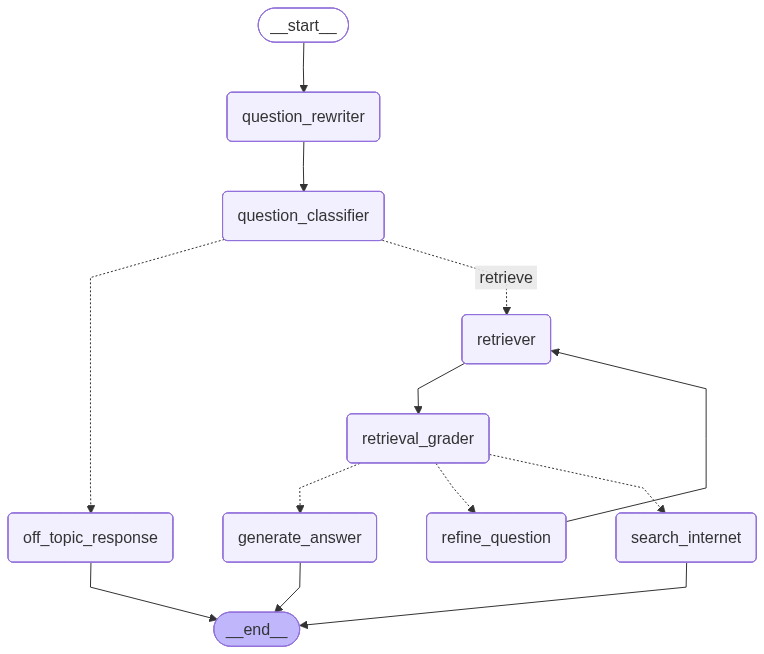

In [54]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

def visualize_graph(compiled_graph):
    """
    Renders the LangGraph architecture and displays it directly in the notebook.
    Provides a raw Mermaid fallback if the API fails, without saving any files.
    """
    print("\n" + "="*60)
    print("🎨 GENERATING GRAPH VISUALIZATION...")
    print("="*60)

    try:
        # 1. Generate the image payload via Mermaid API (held in memory)
        graph_png = compiled_graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )

        # 2. Display the image inline directly
        print("👇 Displaying Graph:")
        display(Image(graph_png))

    except Exception as e:
        # 3. The Fallback (If the API is down or the graph is too large)
        print(f"⚠️ WARNING: Failed to generate PNG via Mermaid API.\nError: {e}")
        print("\n⬇️ RESCUING DATA: Here is the raw Mermaid code instead.")
        print("You can paste this directly into a Notion /mermaid block, GitHub, or https://mermaid.live/")

        raw_mermaid = compiled_graph.get_graph().draw_mermaid()
        print("\n```mermaid\n" + raw_mermaid + "\n```")

# --- How to use it ---
# Assuming your compiled workflow is named 'graph'
visualize_graph(graph)

In [55]:
print("\n\n" + "="*60)
print("🧪 RUNNING TEST: The Off-Topic Guardrail")
print("="*60)

# 1. Define the completely unrelated question
test_question = "What does the company Apple do?"
print(f"\n[USER INPUT]: '{test_question}'\n")

input_data = {"question": HumanMessage(content=test_question)}

# 2. Assign a unique thread ID for this specific conversation test
# (Using a descriptive string is safer than an integer for SQL checkpointers)
config = {"configurable": {"thread_id": "off_topic_test_1"}}

# 3. Stream the execution to watch our X-Ray logs in real-time!
print("Starting Graph Execution...\n")

for output in graph.stream(input_data, config=config):
    # LangGraph yields updates after every single node finishes.
    # We use 'pass' here because our internal node print statements will do all the talking!
    pass

# 4. Fetch and display the final, clean result
print("\n\n" + "="*60)
print("🎯 FINAL AGENT RESPONSE:")
print("="*60)

# We grab the final memory state directly from the SQLite checkpointer
final_state = graph.get_state(config).values
final_messages = final_state.get("messages", [])

if final_messages:
    # The absolute last message in the array is the AI's final answer
    print(f"\n{final_messages[-1].content}\n")
else:
    print("Error: No messages found in final state.")



🧪 RUNNING TEST: The Off-Topic Guardrail

[USER INPUT]: 'What does the company Apple do?'

Starting Graph Execution...



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending question from: 'content='What does the company Apple do?' additional_kwargs={} response_metadata={}'

[STEP 3] Analyzing conversation length. Total messages in State: 1
  -> NO HISTORY: This is the very first question. Skipping the rewrite phase.

✅ EXITING NODE: question_rewriter (Passing state to the Router)



🚦 ENTERING NODE: question_classifier

[STEP 1] Reading the target question from state:
  -> Question to evaluate: 'What does the company Apple do?'

[STEP 2] Building the Classification Prompt...
  -> Prompt successfully assembled with strict topical rules.

[STEP 3] Forcing the LLM to use the 'GradeQuestion' JSON Schema...

[STEP 4] Sending the payload to Groq...

[STEP 

In [56]:
print("\n\n" + "="*60)
print("🧪 RUNNING TEST: The Off-Topic Guardrail")
print("="*60)

# 1. Define the completely unrelated question
test_question = "What does the company Apple do?"
print(f"\n[USER INPUT]: '{test_question}'\n")

input_data = {"question": HumanMessage(content=test_question)}

# 2. Assign a unique thread ID for this specific conversation test
# (Using a descriptive string is safer than an integer for SQL checkpointers)
config = {"configurable": {"thread_id": "off_topic_test_1"}}

# 3. Stream the execution to watch our X-Ray logs in real-time!
print("Starting Graph Execution...\n")

for output in graph.stream(input_data, config=config):
    # LangGraph yields updates after every single node finishes.
    # We use 'pass' here because our internal node print statements will do all the talking!
    pass

# 4. Fetch and display the final, clean result
print("\n\n" + "="*60)
print("🎯 FINAL AGENT RESPONSE:")
print("="*60)

# We grab the final memory state directly from the SQLite checkpointer
final_state = graph.get_state(config).values
final_messages = final_state.get("messages", [])

if final_messages:
    # The absolute last message in the array is the AI's final answer
    print(f"\n{final_messages[-1].content}\n")
else:
    print("Error: No messages found in final state.")



🧪 RUNNING TEST: The Off-Topic Guardrail

[USER INPUT]: 'What does the company Apple do?'

Starting Graph Execution...



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending question from: 'content='What does the company Apple do?' additional_kwargs={} response_metadata={}'

[STEP 3] Analyzing conversation length. Total messages in State: 3
  -> HISTORY FOUND: We need to check if the new question has ambiguous pronouns.

   [3A] Extracting Past Conversation:

   [4A] Provide system Prompt

   [4B] Provide coversation (context)

   [4C] Final Prompt Array ready to be sent to Groq:
        [0] SystemMessage: You are a helpful assistant that rephrases the user's question to be a standalone question optimized for retrieval.
        [1] HumanMessage: What does the company Apple do?
        [2] AIMessage: Thanks for your question! I’m here to help with fina

In [57]:
input_data = {
    "question": HumanMessage(
        content="hi there My name is Sachin, how are you doing today?"
    )
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending question from: 'content='hi there My name is Sachin, how are you doing today?' additional_kwargs={} response_metadata={}'

[STEP 3] Analyzing conversation length. Total messages in State: 1
  -> NO HISTORY: This is the very first question. Skipping the rewrite phase.

✅ EXITING NODE: question_rewriter (Passing state to the Router)



🚦 ENTERING NODE: question_classifier

[STEP 1] Reading the target question from state:
  -> Question to evaluate: 'hi there My name is Sachin, how are you doing today?'

[STEP 2] Building the Classification Prompt...
  -> Prompt successfully assembled with strict topical rules.

[STEP 3] Forcing the LLM to use the 'GradeQuestion' JSON Schema...

[STEP 4] Sending the payload to Groq...

[STEP 5] Output intercepted from LLM!
  -> Object Type: GradeQuestion
  -> Raw Object

{'messages': [HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='c446ec82-5b24-4083-be9c-d84aceee0b63'),
  AIMessage(content='Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  \nJust a quick reminder—I’m specifically designed to answer finance‑related questions, especially about JPM 2023 reports and the JPM SE Annual report. If you have any questions in that area, feel free to ask, and I’ll be happy to provide the information you need.', additional_kwargs={}, response_metadata={}, id='eb7468c7-0170-4c21-9586-33ee1783dcd2', tool_calls=[], invalid_tool_calls=[])],
 'documents': [],
 'on_topic': 'No',
 'rephrased_question': 'hi there My name is Sachin, how are you doing today?',
 'proceed_to_generate': False,
 'rephrase_count': 0,
 'question': HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='c446e

In [58]:
input_data = {
    "question": HumanMessage(
        content="hi there My name is Sachin, how are you doing today?"
    )
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending question from: 'content='hi there My name is Sachin, how are you doing today?' additional_kwargs={} response_metadata={}'

[STEP 3] Analyzing conversation length. Total messages in State: 3
  -> HISTORY FOUND: We need to check if the new question has ambiguous pronouns.

   [3A] Extracting Past Conversation:

   [4A] Provide system Prompt

   [4B] Provide coversation (context)

   [4C] Final Prompt Array ready to be sent to Groq:
        [0] SystemMessage: You are a helpful assistant that rephrases the user's question to be a standalone question optimized for retrieval.
        [1] HumanMessage: hi there My name is Sachin, how are you doing today?
        [2] AIMessage: Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  
Just a quick reminder—I’m specifica

{'messages': [HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='c446ec82-5b24-4083-be9c-d84aceee0b63'),
  AIMessage(content='Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  \nJust a quick reminder—I’m specifically designed to answer finance‑related questions, especially about JPM 2023 reports and the JPM SE Annual report. If you have any questions in that area, feel free to ask, and I’ll be happy to provide the information you need.', additional_kwargs={}, response_metadata={}, id='eb7468c7-0170-4c21-9586-33ee1783dcd2', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='ceac65f2-3b32-442e-9832-e71298b1c2e8'),
  AIMessage(content='I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you with any finance‑related questions you have

In [59]:
input_data = {
    "question": HumanMessage(
        content="do you remeber my name?"
    )
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending question from: 'content='do you remeber my name?' additional_kwargs={} response_metadata={}'

[STEP 3] Analyzing conversation length. Total messages in State: 5
  -> HISTORY FOUND: We need to check if the new question has ambiguous pronouns.

   [3A] Extracting Past Conversation:

   [4A] Provide system Prompt

   [4B] Provide coversation (context)

   [4C] Final Prompt Array ready to be sent to Groq:
        [0] SystemMessage: You are a helpful assistant that rephrases the user's question to be a standalone question optimized for retrieval.
        [1] HumanMessage: hi there My name is Sachin, how are you doing today?
        [2] AIMessage: Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  
Just a quick reminder—I’m specifically designed to answer financ

{'messages': [HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='c446ec82-5b24-4083-be9c-d84aceee0b63'),
  AIMessage(content='Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  \nJust a quick reminder—I’m specifically designed to answer finance‑related questions, especially about JPM 2023 reports and the JPM SE Annual report. If you have any questions in that area, feel free to ask, and I’ll be happy to provide the information you need.', additional_kwargs={}, response_metadata={}, id='eb7468c7-0170-4c21-9586-33ee1783dcd2', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='ceac65f2-3b32-442e-9832-e71298b1c2e8'),
  AIMessage(content='I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you with any finance‑related questions you have

In [60]:
input_data = {
    "question": HumanMessage(
        content="okay my name is Sachin, just remember my name whenever ask tell me"
    )
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending question from: 'content='okay my name is Sachin, just remember my name whenever ask tell me' additional_kwargs={} response_metadata={}'

[STEP 3] Analyzing conversation length. Total messages in State: 7
  -> HISTORY FOUND: We need to check if the new question has ambiguous pronouns.

   [3A] Extracting Past Conversation:

   [4A] Provide system Prompt

   [4B] Provide coversation (context)

   [4C] Final Prompt Array ready to be sent to Groq:
        [0] SystemMessage: You are a helpful assistant that rephrases the user's question to be a standalone question optimized for retrieval.
        [1] HumanMessage: hi there My name is Sachin, how are you doing today?
        [2] AIMessage: Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  
Just a quick reminder

{'messages': [HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='c446ec82-5b24-4083-be9c-d84aceee0b63'),
  AIMessage(content='Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  \nJust a quick reminder—I’m specifically designed to answer finance‑related questions, especially about JPM 2023 reports and the JPM SE Annual report. If you have any questions in that area, feel free to ask, and I’ll be happy to provide the information you need.', additional_kwargs={}, response_metadata={}, id='eb7468c7-0170-4c21-9586-33ee1783dcd2', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='ceac65f2-3b32-442e-9832-e71298b1c2e8'),
  AIMessage(content='I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you with any finance‑related questions you have

In [61]:
input_data = {
    "question": HumanMessage(
        content="Hey can you help me write my theis on topic: Computer Science Fundamentals"
    )
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending question from: 'content='Hey can you help me write my theis on topic: Computer Science Fundamentals' additional_kwargs={} response_metadata={}'

[STEP 3] Analyzing conversation length. Total messages in State: 9
  -> HISTORY FOUND: We need to check if the new question has ambiguous pronouns.

   [3A] Extracting Past Conversation:

   [4A] Provide system Prompt

   [4B] Provide coversation (context)

   [4C] Final Prompt Array ready to be sent to Groq:
        [0] SystemMessage: You are a helpful assistant that rephrases the user's question to be a standalone question optimized for retrieval.
        [1] HumanMessage: hi there My name is Sachin, how are you doing today?
        [2] AIMessage: Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  
Just a quick 

{'messages': [HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='c446ec82-5b24-4083-be9c-d84aceee0b63'),
  AIMessage(content='Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  \nJust a quick reminder—I’m specifically designed to answer finance‑related questions, especially about JPM 2023 reports and the JPM SE Annual report. If you have any questions in that area, feel free to ask, and I’ll be happy to provide the information you need.', additional_kwargs={}, response_metadata={}, id='eb7468c7-0170-4c21-9586-33ee1783dcd2', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='ceac65f2-3b32-442e-9832-e71298b1c2e8'),
  AIMessage(content='I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you with any finance‑related questions you have

In [62]:
input_data = {
    "question": HumanMessage(
        content="can you tell me apples current stock price ?"
    )
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending question from: 'content='can you tell me apples current stock price ?' additional_kwargs={} response_metadata={}'

[STEP 3] Analyzing conversation length. Total messages in State: 11
  -> HISTORY FOUND: We need to check if the new question has ambiguous pronouns.

   [3A] Extracting Past Conversation:

   [4A] Provide system Prompt

   [4B] Provide coversation (context)

   [4C] Final Prompt Array ready to be sent to Groq:
        [0] SystemMessage: You are a helpful assistant that rephrases the user's question to be a standalone question optimized for retrieval.
        [1] HumanMessage: hi there My name is Sachin, how are you doing today?
        [2] AIMessage: Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  
Just a quick reminder—I’m specifically des

{'messages': [HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='c446ec82-5b24-4083-be9c-d84aceee0b63'),
  AIMessage(content='Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  \nJust a quick reminder—I’m specifically designed to answer finance‑related questions, especially about JPM 2023 reports and the JPM SE Annual report. If you have any questions in that area, feel free to ask, and I’ll be happy to provide the information you need.', additional_kwargs={}, response_metadata={}, id='eb7468c7-0170-4c21-9586-33ee1783dcd2', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='ceac65f2-3b32-442e-9832-e71298b1c2e8'),
  AIMessage(content='I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you with any finance‑related questions you have

In [63]:
input_data = {
    "question": HumanMessage(
        content="tell me about JPM JOURNEY TO THE CLOUD?"
    )
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending question from: 'content='tell me about JPM JOURNEY TO THE CLOUD?' additional_kwargs={} response_metadata={}'

[STEP 3] Analyzing conversation length. Total messages in State: 13
  -> HISTORY FOUND: We need to check if the new question has ambiguous pronouns.

   [3A] Extracting Past Conversation:

   [4A] Provide system Prompt

   [4B] Provide coversation (context)

   [4C] Final Prompt Array ready to be sent to Groq:
        [0] SystemMessage: You are a helpful assistant that rephrases the user's question to be a standalone question optimized for retrieval.
        [1] HumanMessage: hi there My name is Sachin, how are you doing today?
        [2] AIMessage: Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  
Just a quick reminder—I’m specifically designed

{'messages': [HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='c446ec82-5b24-4083-be9c-d84aceee0b63'),
  AIMessage(content='Hi Sachin! I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you.  \nJust a quick reminder—I’m specifically designed to answer finance‑related questions, especially about JPM 2023 reports and the JPM SE Annual report. If you have any questions in that area, feel free to ask, and I’ll be happy to provide the information you need.', additional_kwargs={}, response_metadata={}, id='eb7468c7-0170-4c21-9586-33ee1783dcd2', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}, id='ceac65f2-3b32-442e-9832-e71298b1c2e8'),
  AIMessage(content='I’m just a virtual assistant, so I don’t have feelings, but I’m ready to help you with any finance‑related questions you have

In [64]:
input_data = {
    "question": HumanMessage(content="what are the Tangible Book Value and Average Stock Price per Share from 2005–2023 of JPM in tabular format")
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 2}})



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending question from: 'content='what are the Tangible Book Value and Average Stock Price per Share from 2005–2023 of JPM in tabular format' additional_kwargs={} response_metadata={}'

[STEP 3] Analyzing conversation length. Total messages in State: 1
  -> NO HISTORY: This is the very first question. Skipping the rewrite phase.

✅ EXITING NODE: question_rewriter (Passing state to the Router)



🚦 ENTERING NODE: question_classifier

[STEP 1] Reading the target question from state:
  -> Question to evaluate: 'what are the Tangible Book Value and Average Stock Price per Share from 2005–2023 of JPM in tabular format'

[STEP 2] Building the Classification Prompt...
  -> Prompt successfully assembled with strict topical rules.

[STEP 3] Forcing the LLM to use the 'GradeQuestion' JSON Schema...

[STEP 4] Sending t

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01krhb6aypfpnbt990n65p2jws` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Used 4913, Requested 3547. Please try again in 3.45s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
input_data = {
    "question": HumanMessage(content="explain me the concept of blockchain?")
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 3}})



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending: 'explain me the concept of blockchain?'

[STEP 3] Analyzing conversation length. Total messages in State: 1
  -> NO HISTORY: This is the very first question. Skipping the rewrite phase.

✅ EXITING NODE: question_rewriter (Passing state to the Router)



🚦 ENTERING NODE: question_classifier

[STEP 1] Reading the target question from state:
  -> Question to evaluate: 'explain me the concept of blockchain?'

[STEP 2] Building the Classification Prompt...
  -> Prompt successfully assembled with strict topical rules.

[STEP 3] Forcing the LLM to use the 'GradeQuestion' JSON Schema...

[STEP 4] Sending the payload to Groq...

[STEP 5] Output intercepted from LLM!
  -> Object Type: GradeQuestion
  -> Raw Object Data: score='Yes'

🌟 RESULT: Classification Complete!
  -> state['on_topic'] was successfully o

{'messages': [HumanMessage(content='explain me the concept of blockchain?', additional_kwargs={}, response_metadata={}, id='08d5556f-16d0-4ac8-845b-bfbef484607a'),
  AIMessage(content='[\'Blockchain is a decentralized digital database or ledger that securely stores records across a network of computers in a way that is transparent, immutable, ...\', \'Blockchain technology is an advanced database mechanism that allows transparent information sharing within a business network.\', \'Blockchain is a shared, immutable digital ledger, enabling the recording of transactions and the tracking of assets within a business network.\', "This guide is designed to provide novice learners with an introductory understanding of blockchain technology. As we release this guide, it\'s important to ...", "Blockchain, as it\'s moniker suggests, is blocks of data linked into an uneditable, digital chain. This information is stored in an open-source decentralized ...", \'Blockchains can be informally defined 

In [ ]:
input_data = {"question": HumanMessage(content="what is fund transfer pricing?")}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 3}})



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending: 'what is fund transfer pricing?'

[STEP 3] Analyzing conversation length. Total messages in State: 3
  -> HISTORY FOUND: We need to check if the new question has ambiguous pronouns.

   [3A] Extracted Past Conversation:
        - HumanMessage: explain me the concept of blockchain?
        - AIMessage: ['Blockchain is a decentralized digital database or ledger that securely stores records across a network of computers in a way that is transparent, immutable, ...', 'Blockchain technology is an advanced database mechanism that allows transparent information sharing within a business network.', 'Blockchain is a shared, immutable digital ledger, enabling the recording of transactions and the tracking of assets within a business network.', "This guide is designed to provide novice learners with an introd

{'messages': [HumanMessage(content='explain me the concept of blockchain?', additional_kwargs={}, response_metadata={}, id='08d5556f-16d0-4ac8-845b-bfbef484607a'),
  AIMessage(content='[\'Blockchain is a decentralized digital database or ledger that securely stores records across a network of computers in a way that is transparent, immutable, ...\', \'Blockchain technology is an advanced database mechanism that allows transparent information sharing within a business network.\', \'Blockchain is a shared, immutable digital ledger, enabling the recording of transactions and the tracking of assets within a business network.\', "This guide is designed to provide novice learners with an introductory understanding of blockchain technology. As we release this guide, it\'s important to ...", "Blockchain, as it\'s moniker suggests, is blocks of data linked into an uneditable, digital chain. This information is stored in an open-source decentralized ...", \'Blockchains can be informally defined 

In [ ]:
input_data = {"question": HumanMessage(content="what is the mechanism behind it?")}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 3}})



ENTERING NODE: question_rewriter

[STEP 1] Wiping temporary RAG memory clean for the new turn...

[STEP 2] Performing Deduplication Check...
  -> SUCCESS: New question detected. Appending: 'what is the mechanism behind it?'

[STEP 3] Analyzing conversation length. Total messages in State: 5
  -> HISTORY FOUND: We need to check if the new question has ambiguous pronouns.

   [3A] Extracted Past Conversation:
        - HumanMessage: explain me the concept of blockchain?
        - AIMessage: ['Blockchain is a decentralized digital database or ledger that securely stores records across a network of computers in a way that is transparent, immutable, ...', 'Blockchain technology is an advanced database mechanism that allows transparent information sharing within a business network.', 'Blockchain is a shared, immutable digital ledger, enabling the recording of transactions and the tracking of assets within a business network.', "This guide is designed to provide novice learners with an intr

{'messages': [HumanMessage(content='explain me the concept of blockchain?', additional_kwargs={}, response_metadata={}, id='08d5556f-16d0-4ac8-845b-bfbef484607a'),
  AIMessage(content='[\'Blockchain is a decentralized digital database or ledger that securely stores records across a network of computers in a way that is transparent, immutable, ...\', \'Blockchain technology is an advanced database mechanism that allows transparent information sharing within a business network.\', \'Blockchain is a shared, immutable digital ledger, enabling the recording of transactions and the tracking of assets within a business network.\', "This guide is designed to provide novice learners with an introductory understanding of blockchain technology. As we release this guide, it\'s important to ...", "Blockchain, as it\'s moniker suggests, is blocks of data linked into an uneditable, digital chain. This information is stored in an open-source decentralized ...", \'Blockchains can be informally defined 

In [ ]:
import os

db_files = [
    "financebot_new.sqlite",
    "financebot_new.sqlite-shm",
    "financebot_new.sqlite-wal",
]

for f in db_files:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted: {f}")
    else:
        print(f"Not found: {f}")

print("\nSQLite DB cleaned up. Re-run the graph-building cell to start fresh.")